## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from skimage.feature import hog

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

In [2]:
print("Loading data...")
data_path = './assets/mnist_merged_original+full+partial.npz'
data = np.load(data_path)

print(f"\nData loaded successfully!")
print(f"Data keys: {list(data.keys())}")
print()

for key in data.keys():
    print(f"[{key}]")
    print(f"  Shape: {data[key].shape}")
    print(f"  Dtype: {data[key].dtype}")
    print()

Loading data...

Data loaded successfully!
Data keys: ['train_images', 'digit_labels', 'fg_color_labels', 'bg_color_labels']

[train_images]
  Shape: (70000, 28, 28, 3)
  Dtype: uint8

[digit_labels]
  Shape: (70000,)
  Dtype: int64

[fg_color_labels]
  Shape: (70000,)
  Dtype: uint8

[bg_color_labels]
  Shape: (70000,)
  Dtype: uint8



## 3. Data Preprocessing

In [3]:
# Color definitions
RAINBOW_COLORS = [
    (255, 0, 0),    # Red
    (255, 127, 0),  # Orange
    (255, 255, 0),  # Yellow  
    (0, 255, 0),    # Green
    (0, 0, 255),    # Blue
    (75, 0, 130),   # Indigo
    (148, 0, 211)   # Violet
]

RAINBOW_NAMES = [
    'RED',
    'ORANGE',
    'YELLOW',
    'GREEN',
    'BLUE',
    'INDIGO',
    'VIOLET'
]

DIGIT_CLASSES = list(range(10))  # 0-9

print("Label definitions:")
print(f"  Digit classes: {DIGIT_CLASSES}")
print(f"  Color classes: {RAINBOW_NAMES}")
print(f"  Number of color classes: {len(RAINBOW_NAMES)}")


Label definitions:
  Digit classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Color classes: ['RED', 'ORANGE', 'YELLOW', 'GREEN', 'BLUE', 'INDIGO', 'VIOLET']
  Number of color classes: 7


In [4]:
train_images = data['train_images']
train_labels = data['digit_labels']
fg_labels = data['fg_color_labels']
bg_labels = data['bg_color_labels']

print(f"Data extraction completed")
print(f"  Images shape: {train_images.shape}")
print(f"  Digit labels shape: {train_labels.shape}")
print(f"  Foreground labels shape: {fg_labels.shape}")
print(f"  Background labels shape: {bg_labels.shape}")

Data extraction completed
  Images shape: (70000, 28, 28, 3)
  Digit labels shape: (70000,)
  Foreground labels shape: (70000,)
  Background labels shape: (70000,)


In [5]:
print("\nFlattening images...")
if len(train_images.shape) == 4:
    X_flat = train_images.reshape(train_images.shape[0], -1)
    print(f"  RGB images: {train_images.shape} -> {X_flat.shape}")
elif len(train_images.shape) == 3:
    X_flat = train_images.reshape(train_images.shape[0], -1)
    print(f"  Grayscale images: {train_images.shape} -> {X_flat.shape}")
else:
    X_flat = train_images
    print(f"  Already flattened: {X_flat.shape}")

X_normalized = X_flat / 255.0
print(f"Normalization completed (range: {X_normalized.min():.2f} ~ {X_normalized.max():.2f})")


Flattening images...
  RGB images: (70000, 28, 28, 3) -> (70000, 2352)
Normalization completed (range: 0.00 ~ 1.00)


## 4. Data Visualization

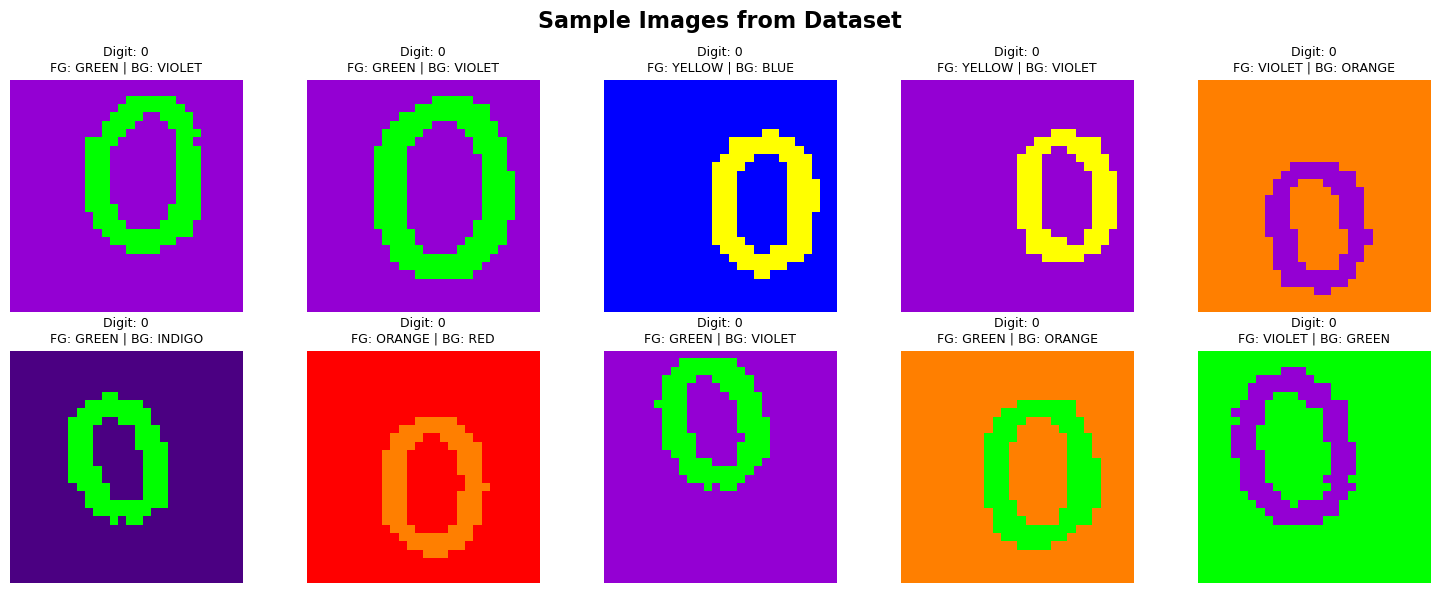

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(train_images):
        img = train_images[i]
        
        if len(img.shape) == 3 and img.shape[2] == 3:
            ax.imshow(img)
        elif len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img.squeeze(), cmap='gray')
        
        title = f'Digit: {train_labels[i]}'
        if fg_labels is not None:
            fg_idx = int(fg_labels[i])
            fg_name = RAINBOW_NAMES[fg_idx] if fg_idx < len(RAINBOW_NAMES) else str(fg_idx)
            title += f'\nFG: {fg_name}'
        if bg_labels is not None:
            bg_idx = int(bg_labels[i])
            bg_name = RAINBOW_NAMES[bg_idx] if bg_idx < len(RAINBOW_NAMES) else str(bg_idx)
            title += f' | BG: {bg_name}'
        
        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()


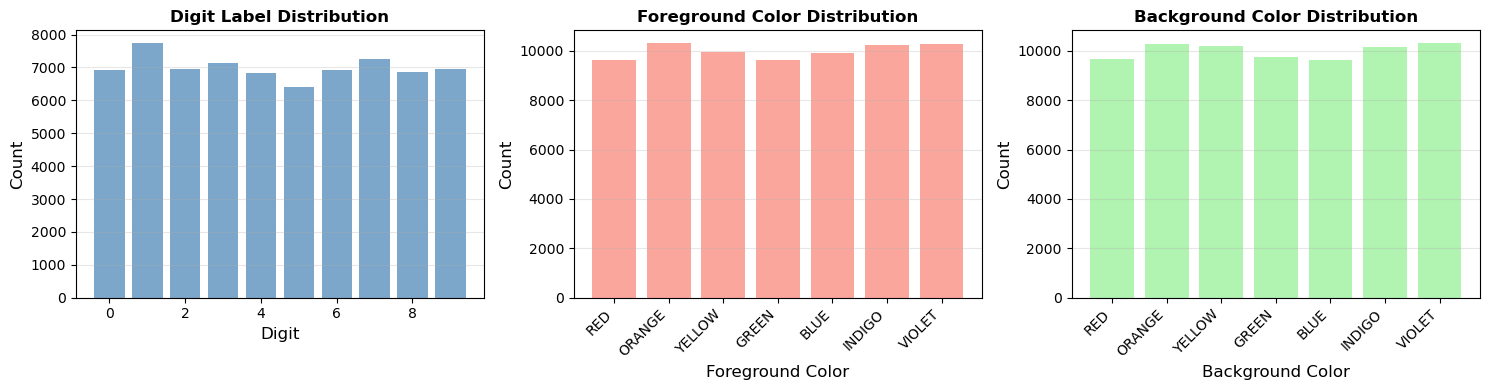

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax1 = axes[0]
unique, counts = np.unique(train_labels, return_counts=True)
ax1.bar(unique, counts, color='steelblue', alpha=0.7)
ax1.set_xlabel('Digit', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Digit Label Distribution', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

if fg_labels is not None:
    ax2 = axes[1]
    unique, counts = np.unique(fg_labels, return_counts=True)
    ax2.bar(unique, counts, color='salmon', alpha=0.7)
    ax2.set_xlabel('Foreground Color', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('Foreground Color Distribution', fontsize=12, fontweight='bold')
    ax2.set_xticks(unique)
    ax2.set_xticklabels([RAINBOW_NAMES[int(i)] if int(i) < len(RAINBOW_NAMES) else str(i) for i in unique], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No FG Labels', ha='center', va='center', 
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].axis('off')

if bg_labels is not None:
    ax3 = axes[2]
    unique, counts = np.unique(bg_labels, return_counts=True)
    ax3.bar(unique, counts, color='lightgreen', alpha=0.7)
    ax3.set_xlabel('Background Color', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.set_title('Background Color Distribution', fontsize=12, fontweight='bold')
    ax3.set_xticks(unique)
    ax3.set_xticklabels([RAINBOW_NAMES[int(i)] if int(i) < len(RAINBOW_NAMES) else str(i) for i in unique], rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No BG Labels', ha='center', va='center', 
                 transform=axes[2].transAxes, fontsize=14)
    axes[2].axis('off')

plt.tight_layout()
plt.show()


## 5. Train/Test Split

In [8]:
test_size = 0.2
random_state = 42

print(f"Splitting data (Test size: {test_size*100}%)...")

X_train, X_test, y_digit_train, y_digit_test = train_test_split(
    X_normalized, train_labels, 
    test_size=test_size, 
    random_state=random_state, 
    stratify=train_labels
)

if fg_labels is not None:
    y_fg_train = fg_labels[y_digit_train.index] if hasattr(y_digit_train, 'index') else fg_labels[:len(y_digit_train)]
    y_fg_test = fg_labels[y_digit_test.index] if hasattr(y_digit_test, 'index') else fg_labels[len(y_digit_train):]
    
    _, _, y_fg_train, y_fg_test = train_test_split(
        X_normalized, fg_labels, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=train_labels
    )
else:
    y_fg_train = y_fg_test = None

if bg_labels is not None:
    _, _, y_bg_train, y_bg_test = train_test_split(
        X_normalized, bg_labels, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=train_labels
    )
else:
    y_bg_train = y_bg_test = None

print(f"Split completed")
print(f"  Train: {X_train.shape[0]:,} samples")
print(f"  Test:  {X_test.shape[0]:,} samples")
print(f"  Features: {X_train.shape[1]:,}")


Splitting data (Test size: 20.0%)...
Split completed
  Train: 56,000 samples
  Test:  14,000 samples
  Features: 2,352


## 6. HOG Feature Extraction (for SVM)

In [9]:
print("Extracting HOG features for SVM models...")
print("This may take a few minutes...")

def extract_hog_features(images):
    """Extract HOG features from images"""
    hog_features = []
    
    for i, img in enumerate(images):
        if i % 10000 == 0:
            print(f"  Processing {i}/{len(images)}...")
        
        if len(img.shape) == 1:
            if img.shape[0] == 2352:
                img = img.reshape(28, 28, 3)
            elif img.shape[0] == 784:
                img = img.reshape(28, 28)

        if len(img.shape) == 3:
            img_gray = np.dot(img[...,:3], [0.299, 0.587, 0.114])
        else:
            img_gray = img

        features = hog(
            img_gray, 
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False
        )
        hog_features.append(features)
    
    return np.array(hog_features)

X_train_hog = extract_hog_features(X_train.reshape(-1, 28, 28, 3) if X_train.shape[1] == 2352 else X_train.reshape(-1, 28, 28))
X_test_hog = extract_hog_features(X_test.reshape(-1, 28, 28, 3) if X_test.shape[1] == 2352 else X_test.reshape(-1, 28, 28))

print(f"\nHOG feature extraction completed!")
print(f"  Train HOG features shape: {X_train_hog.shape}")
print(f"  Test HOG features shape: {X_test_hog.shape}")
print(f"\nNote: Raw pixel features are still available for other models")
print(f"  Train raw shape: {X_train.shape}")
print(f"  Test raw shape: {X_test.shape}")

Extracting HOG features for SVM models...
This may take a few minutes...
  Processing 0/56000...
  Processing 10000/56000...
  Processing 20000/56000...
  Processing 30000/56000...
  Processing 40000/56000...
  Processing 50000/56000...
  Processing 0/14000...
  Processing 10000/14000...

HOG feature extraction completed!
  Train HOG features shape: (56000, 144)
  Test HOG features shape: (14000, 144)

Note: Raw pixel features are still available for other models
  Train raw shape: (56000, 2352)
  Test raw shape: (14000, 2352)


## 7. Model Definition


In [10]:
def get_models():
    """Return a fresh set of models for each training task"""
    return {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=20, 
            random_state=42
        ),
        'K-Nearest Neighbors': KNeighborsClassifier(
            n_neighbors=5, 
            n_jobs=1
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=100, 
            random_state=42, 
            n_jobs=1,
            solver='saga'
        ),
        'SVM (Linear)': SVC(
            kernel='linear', 
            random_state=42, 
            max_iter=100
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', 
            random_state=42, 
            max_iter=100,
            gamma='scale'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            random_state=42,
            n_jobs=1
        ),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=100,
            max_depth=20,
            random_state=42,
            n_jobs=1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=1,
            verbosity=0
        ),
        'HOG + SVM (Linear)': SVC(
            kernel='linear', 
            random_state=42, 
            max_iter=100
        ),
        'HOG + SVM (RBF)': SVC(
            kernel='rbf', 
            random_state=42, 
            max_iter=100,
            gamma='scale'
        )
    }

print("Model definition completed")
print(f"Number of models: {len(get_models())}")
for name in get_models().keys():
    print(f"  - {name}")

Model definition completed
Number of models: 10
  - Decision Tree
  - K-Nearest Neighbors
  - Logistic Regression
  - SVM (Linear)
  - SVM (RBF)
  - Random Forest
  - Extra Trees
  - XGBoost
  - HOG + SVM (Linear)
  - HOG + SVM (RBF)


## 8. Model Training and Evaluation


In [11]:
def train_and_evaluate(models, X_train, X_test, X_train_hog, X_test_hog, y_train, y_test, task_name='Classification'):
    print(f"\n{'='*70}")
    print(f"{task_name}")
    print(f"{'='*70}\n")
    
    print(f"[DEBUG] Received {len(models)} models to train")
    print(f"[DEBUG] Model names: {list(models.keys())}\n")
    
    results = []
    
    for idx, (name, model) in enumerate(models.items(), 1):
        print(f"[{idx}/{len(models)}] Training {name}...")
        start_time = time.time()
        
        try:
            if 'HOG' in name:
                X_train_use = X_train_hog
                X_test_use = X_test_hog
                print(f"  Using HOG features: {X_train_use.shape}")
            else:
                X_train_use = X_train
                X_test_use = X_test
            
            model.fit(X_train_use, y_train)
            
            y_pred = model.predict(X_test_use)
            
            accuracy = accuracy_score(y_test, y_pred)
            
            elapsed = time.time() - start_time
            
            print(f"  Completed - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%) | Time: {elapsed:.2f}s\n")
            
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Accuracy (%)': accuracy * 100,
                'Time (s)': elapsed
            })
            
        except Exception as e:
            print(f"  Error occurred: {e}\n")
            results.append({
                'Model': name,
                'Accuracy': 0,
                'Accuracy (%)': 0,
                'Time (s)': 0
            })
    
    print(f"[DEBUG] Training completed. Generated {len(results)} results.\n")
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    
    return results_df

## 9. Task 1: Digit Classification


In [12]:
models_dict = get_models()
print(f"Number of models to train: {len(models_dict)}")
print(f"Model names: {list(models_dict.keys())}")
print()

digit_results = train_and_evaluate(
    models_dict, 
    X_train, 
    X_test, 
    X_train_hog,
    X_test_hog,
    y_digit_train, 
    y_digit_test,
    task_name='Digit Classification'
)

print("\nDigit Classification Results:")
print(digit_results.to_string(index=False))
print()


Number of models to train: 10
Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)', 'Random Forest', 'Extra Trees', 'XGBoost', 'HOG + SVM (Linear)', 'HOG + SVM (RBF)']


Digit Classification

[DEBUG] Received 10 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)', 'Random Forest', 'Extra Trees', 'XGBoost', 'HOG + SVM (Linear)', 'HOG + SVM (RBF)']

[1/10] Training Decision Tree...
  Completed - Accuracy: 0.4015 (40.15%) | Time: 29.15s

[2/10] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.8420 (84.20%) | Time: 9.34s

[3/10] Training Logistic Regression...
  Completed - Accuracy: 0.1761 (17.61%) | Time: 791.44s

[4/10] Training SVM (Linear)...
  Completed - Accuracy: 0.1196 (11.96%) | Time: 246.46s

[5/10] Training SVM (RBF)...
  Completed - Accuracy: 0.1134 (11.34%) | Time: 300.36s

[6/10] Training Random Forest...
  Completed - Accuracy: 0.8725 (87

## 10. Task 2: Foreground Color Classification


In [13]:
if y_fg_train is not None and y_fg_test is not None:
    fg_results = train_and_evaluate(
        get_models(), 
        X_train, 
        X_test, 
        X_train_hog,
        X_test_hog,
        y_fg_train, 
        y_fg_test,
        task_name='Foreground Color Classification'
    )
    
    print("\nForeground Color Classification Results:")
    print(fg_results.to_string(index=False))
    print()
else:
    print("\nNo foreground labels available. Skipping this task.")
    fg_results = None



Foreground Color Classification

[DEBUG] Received 10 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)', 'Random Forest', 'Extra Trees', 'XGBoost', 'HOG + SVM (Linear)', 'HOG + SVM (RBF)']

[1/10] Training Decision Tree...
  Completed - Accuracy: 0.9366 (93.66%) | Time: 17.81s

[2/10] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.7889 (78.89%) | Time: 8.36s

[3/10] Training Logistic Regression...
  Completed - Accuracy: 0.9726 (97.26%) | Time: 568.72s

[4/10] Training SVM (Linear)...
  Completed - Accuracy: 0.5990 (59.90%) | Time: 100.99s

[5/10] Training SVM (RBF)...
  Completed - Accuracy: 0.6830 (68.30%) | Time: 147.71s

[6/10] Training Random Forest...
  Completed - Accuracy: 0.9966 (99.66%) | Time: 32.40s

[7/10] Training Extra Trees...
  Completed - Accuracy: 0.9964 (99.64%) | Time: 47.42s

[8/10] Training XGBoost...
  Completed - Accuracy: 0.9996 (99.96%) | Time: 240.30s

[9/10] Training H

## 11. Task 3: Background Color Classification


In [14]:
if y_bg_train is not None and y_bg_test is not None:
    bg_results = train_and_evaluate(
        get_models(), 
        X_train, 
        X_test, 
        X_train_hog,
        X_test_hog,
        y_bg_train, 
        y_bg_test,
        task_name='Background Color Classification'
    )
    
    print("\nBackground Color Classification Results:")
    print(bg_results.to_string(index=False))
    print()
else:
    print("\nNo background labels available. Skipping this task.")
    bg_results = None



Background Color Classification

[DEBUG] Received 10 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)', 'Random Forest', 'Extra Trees', 'XGBoost', 'HOG + SVM (Linear)', 'HOG + SVM (RBF)']

[1/10] Training Decision Tree...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 8.56s

[2/10] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 8.34s

[3/10] Training Logistic Regression...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 568.75s

[4/10] Training SVM (Linear)...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 27.13s

[5/10] Training SVM (RBF)...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 63.27s

[6/10] Training Random Forest...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 12.78s

[7/10] Training Extra Trees...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 16.95s

[8/10] Training XGBoost...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 203.58s

[9/10] Training 

## 12. Model Performance Comparison


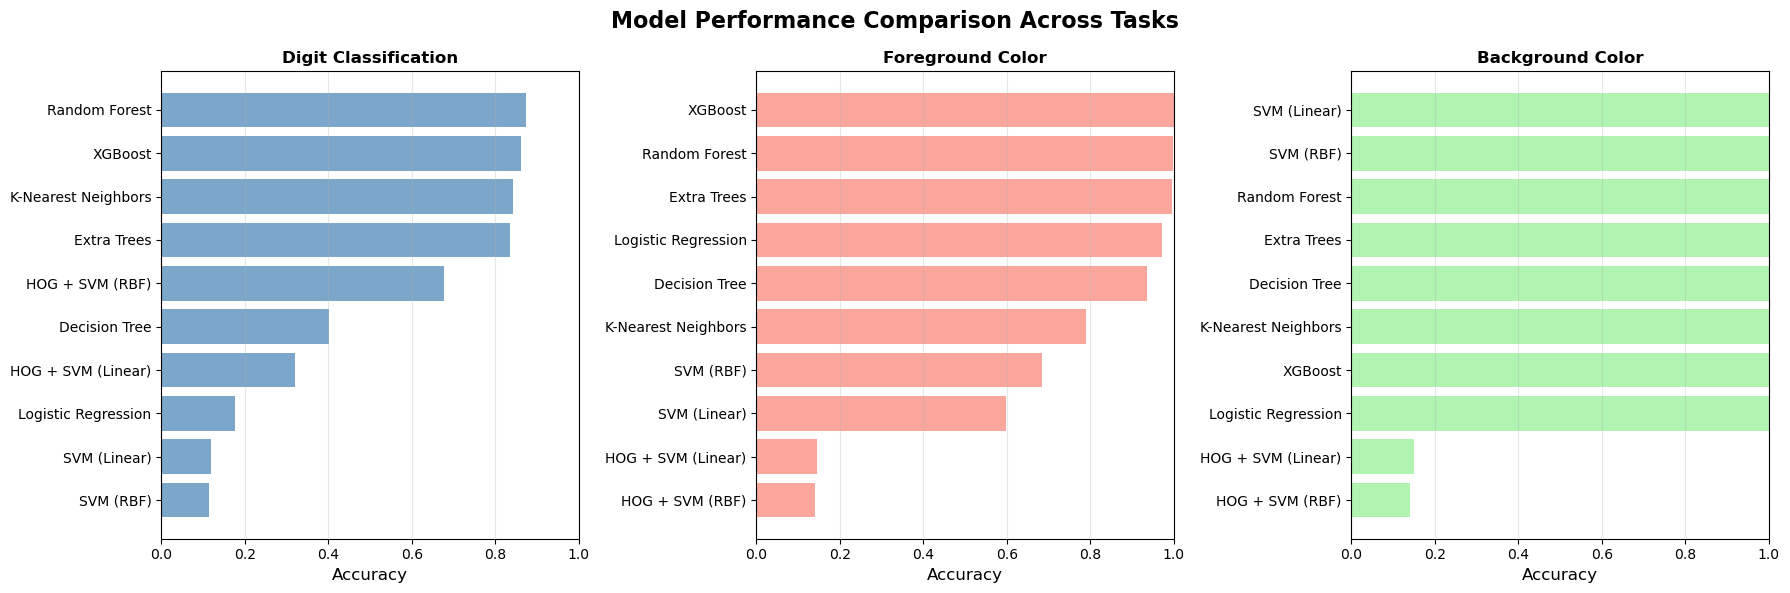

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison Across Tasks', fontsize=16, fontweight='bold')

ax1 = axes[0]
digit_results_sorted = digit_results.sort_values('Accuracy')
ax1.barh(digit_results_sorted['Model'], digit_results_sorted['Accuracy'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Digit Classification', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
if fg_results is not None:
    fg_results_sorted = fg_results.sort_values('Accuracy')
    ax2.barh(fg_results_sorted['Model'], fg_results_sorted['Accuracy'], color='salmon', alpha=0.7)
    ax2.set_xlabel('Accuracy', fontsize=12)
    ax2.set_title('Foreground Color', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 1.0)
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No FG Labels', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Foreground Color', fontsize=12, fontweight='bold')

ax3 = axes[2]
if bg_results is not None:
    bg_results_sorted = bg_results.sort_values('Accuracy')
    ax3.barh(bg_results_sorted['Model'], bg_results_sorted['Accuracy'], color='lightgreen', alpha=0.7)
    ax3.set_xlabel('Accuracy', fontsize=12)
    ax3.set_title('Background Color', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1.0)
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No BG Labels', ha='center', va='center', 
             transform=ax3.transAxes, fontsize=14)
    ax3.set_title('Background Color', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 13. Training Time vs Accuracy Analysis


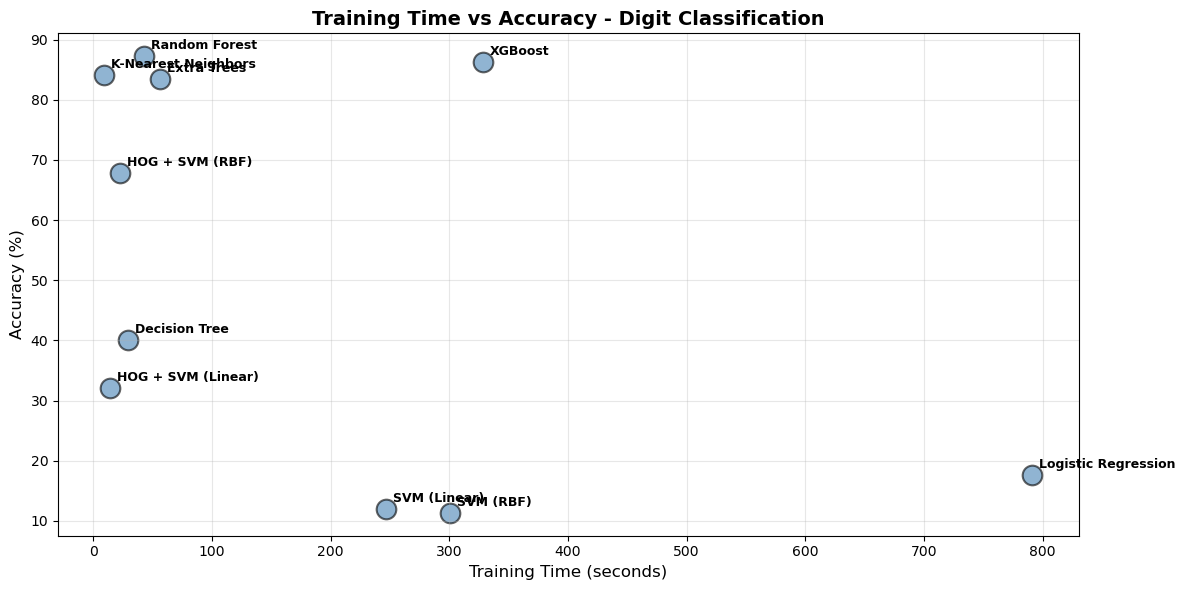


Interpretation:
  - Top left: Fast and accurate models (ideal)
  - Top right: Slow but accurate models
  - Bottom left: Fast but inaccurate models
  - Bottom right: Slow and inaccurate models (worst)


In [16]:
plt.figure(figsize=(12, 6))

plt.scatter(digit_results['Time (s)'], digit_results['Accuracy (%)'], 
           s=200, alpha=0.6, c='steelblue', edgecolors='black', linewidths=1.5)

for i, row in digit_results.iterrows():
    plt.annotate(row['Model'], 
                (row['Time (s)'], row['Accuracy (%)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training Time vs Accuracy - Digit Classification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Top left: Fast and accurate models (ideal)")
print("  - Top right: Slow but accurate models")
print("  - Bottom left: Fast but inaccurate models")
print("  - Bottom right: Slow and inaccurate models (worst)")

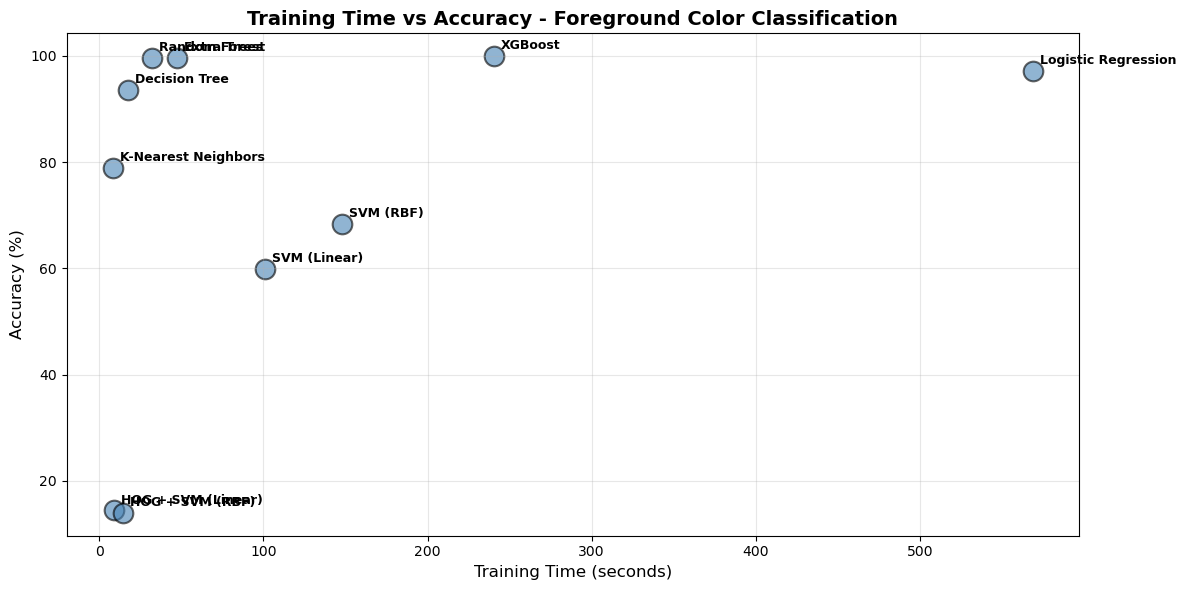


Interpretation:
  - Top left: Fast and accurate models (ideal)
  - Top right: Slow but accurate models
  - Bottom left: Fast but inaccurate models
  - Bottom right: Slow and inaccurate models (worst)


In [17]:
plt.figure(figsize=(12, 6))

plt.scatter(fg_results['Time (s)'], fg_results['Accuracy (%)'], 
           s=200, alpha=0.6, c='steelblue', edgecolors='black', linewidths=1.5)

for i, row in fg_results.iterrows():
    plt.annotate(row['Model'], 
                (row['Time (s)'], row['Accuracy (%)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training Time vs Accuracy - Foreground Color Classification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Top left: Fast and accurate models (ideal)")
print("  - Top right: Slow but accurate models")
print("  - Bottom left: Fast but inaccurate models")
print("  - Bottom right: Slow and inaccurate models (worst)")

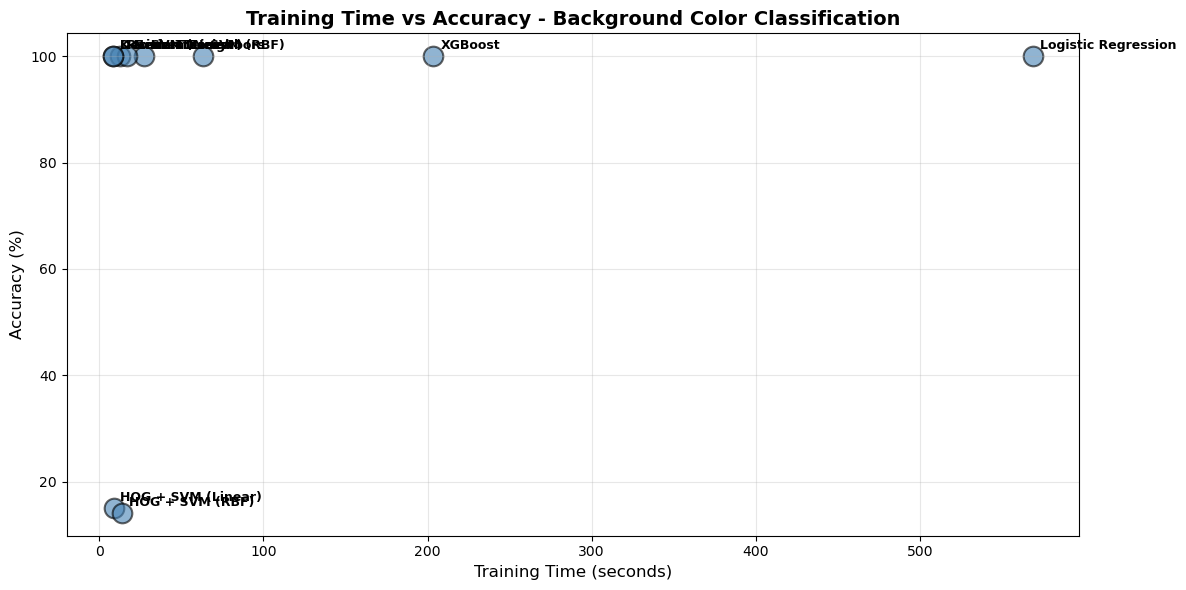


Interpretation:
  - Top left: Fast and accurate models (ideal)
  - Top right: Slow but accurate models
  - Bottom left: Fast but inaccurate models
  - Bottom right: Slow and inaccurate models (worst)


In [18]:
plt.figure(figsize=(12, 6))

plt.scatter(bg_results['Time (s)'], bg_results['Accuracy (%)'], 
           s=200, alpha=0.6, c='steelblue', edgecolors='black', linewidths=1.5)

for i, row in bg_results.iterrows():
    plt.annotate(row['Model'], 
                (row['Time (s)'], row['Accuracy (%)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training Time vs Accuracy - Background Color Classification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Top left: Fast and accurate models (ideal)")
print("  - Top right: Slow but accurate models")
print("  - Bottom left: Fast but inaccurate models")
print("  - Bottom right: Slow and inaccurate models (worst)")

## 14. Summary and Conclusion


In [19]:
print("\n" + "="*70)
print("Experiment Summary")
print("="*70)

print(f"\nDataset: mnist_merged_original+full+partial.npz")
print(f"  - Total samples: {len(train_labels):,}")
print(f"  - Train samples: {len(y_digit_train):,}")
print(f"  - Test samples: {len(y_digit_test):,}")
print(f"  - Feature dimensions: {X_train.shape[1]:,}")

print(f"\nNumber of models tested: {len(get_models())}")

print("\nConclusions:")
print("  - Compared various machine learning models")
print("  - Optimal model may differ for each task")
print("  - Consider accuracy vs training time tradeoff when selecting models")

print("\n" + "="*70)
print("Experiment completed!")
print("="*70)


Experiment Summary

Dataset: mnist_merged_original+full+partial.npz
  - Total samples: 70,000
  - Train samples: 56,000
  - Test samples: 14,000
  - Feature dimensions: 2,352

Number of models tested: 10

Conclusions:
  - Compared various machine learning models
  - Optimal model may differ for each task
  - Consider accuracy vs training time tradeoff when selecting models

Experiment completed!


## 15. Random Forest Confusion Matrices

Training Random Forest models and generating confusion matrices...

[Training Phase] Training Random Forest models...
  [1/3] Training for Digit Classification...
    Accuracy: 0.8725 (87.25%)
  [2/3] Training for Foreground Color Classification...
    Accuracy: 0.8725 (87.25%)
  [2/3] Training for Foreground Color Classification...
    Accuracy: 0.9966 (99.66%)
  [3/3] Training for Background Color Classification...
    Accuracy: 0.9966 (99.66%)
  [3/3] Training for Background Color Classification...
    Accuracy: 1.0000 (100.00%)

All models trained successfully!

Generating Confusion Matrices
    Accuracy: 1.0000 (100.00%)

All models trained successfully!

Generating Confusion Matrices


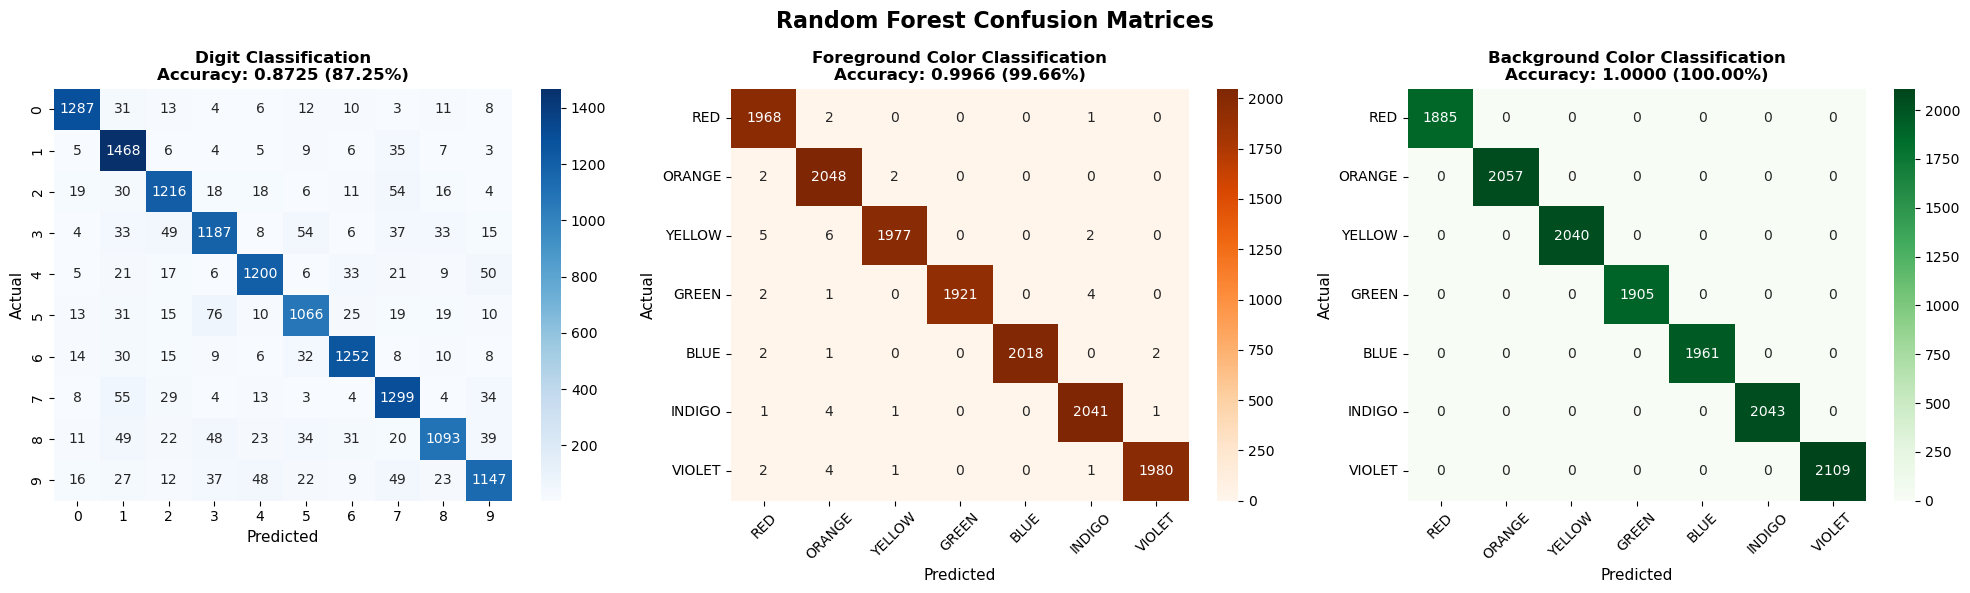


Random Forest Confusion Matrices completed!


In [26]:
print("Training Random Forest models and generating confusion matrices...")
print("="*70)

print("\n[Training Phase] Training Random Forest models...")

print("  [1/3] Training for Digit Classification...")
rf_digit_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=1
)
rf_digit_model.fit(X_train, y_digit_train)
y_digit_pred_rf = rf_digit_model.predict(X_test)
digit_acc = accuracy_score(y_digit_test, y_digit_pred_rf)
print(f"    Accuracy: {digit_acc:.4f} ({digit_acc*100:.2f}%)")

if y_fg_train is not None and y_fg_test is not None:
    print("  [2/3] Training for Foreground Color Classification...")
    rf_fg_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=1
    )
    rf_fg_model.fit(X_train, y_fg_train)
    y_fg_pred_rf = rf_fg_model.predict(X_test)
    fg_acc = accuracy_score(y_fg_test, y_fg_pred_rf)
    print(f"    Accuracy: {fg_acc:.4f} ({fg_acc*100:.2f}%)")
else:
    rf_fg_model = None
    y_fg_pred_rf = None
    print("  [2/3] No foreground labels available.")

if y_bg_train is not None and y_bg_test is not None:
    print("  [3/3] Training for Background Color Classification...")
    rf_bg_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=1
    )
    rf_bg_model.fit(X_train, y_bg_train)
    y_bg_pred_rf = rf_bg_model.predict(X_test)
    bg_acc = accuracy_score(y_bg_test, y_bg_pred_rf)
    print(f"    Accuracy: {bg_acc:.4f} ({bg_acc*100:.2f}%)")
else:
    rf_bg_model = None
    y_bg_pred_rf = None
    print("  [3/3] No background labels available.")

print("\nAll models trained successfully!")
print("\n" + "="*70)
print("Generating Confusion Matrices")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest Confusion Matrices', fontsize=16, fontweight='bold')

cm_digit = confusion_matrix(y_digit_test, y_digit_pred_rf)
sns.heatmap(cm_digit, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=DIGIT_CLASSES, yticklabels=DIGIT_CLASSES)
axes[0].set_title(f'Digit Classification\nAccuracy: {digit_acc:.4f} ({digit_acc*100:.2f}%)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

if y_fg_pred_rf is not None:
    cm_fg = confusion_matrix(y_fg_test, y_fg_pred_rf)
    sns.heatmap(cm_fg, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
    axes[1].set_title(f'Foreground Color Classification\nAccuracy: {fg_acc:.4f} ({fg_acc*100:.2f}%)', 
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted', fontsize=11)
    axes[1].set_ylabel('Actual', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'No FG Labels Available', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Foreground Color Classification', fontsize=12, fontweight='bold')
    axes[1].axis('off')

if y_bg_pred_rf is not None:
    cm_bg = confusion_matrix(y_bg_test, y_bg_pred_rf)
    sns.heatmap(cm_bg, annot=True, fmt='d', cmap='Greens', ax=axes[2],
                xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
    axes[2].set_title(f'Background Color Classification\nAccuracy: {bg_acc:.4f} ({bg_acc*100:.2f}%)', 
                      fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Predicted', fontsize=11)
    axes[2].set_ylabel('Actual', fontsize=11)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].tick_params(axis='y', rotation=0)
else:
    axes[2].text(0.5, 0.5, 'No BG Labels Available', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=14)
    axes[2].set_title('Background Color Classification', fontsize=12, fontweight='bold')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Random Forest Confusion Matrices completed!")
print("="*70)

## 16. Random Forest Classification Reports

In [27]:
print("="*70)
print("Random Forest Classification Reports")
print("="*70)
print("\nUsing previously trained Random Forest models...\n")

print("="*70)
print("[Task 1] Digit Classification Report")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_digit_test, y_digit_pred_rf, 
                          target_names=[str(i) for i in DIGIT_CLASSES],
                          digits=4))

if y_fg_pred_rf is not None:
    print("\n" + "="*70)
    print("[Task 2] Foreground Color Classification Report")
    print("="*70)
    
    print("\nClassification Report:")
    print(classification_report(y_fg_test, y_fg_pred_rf, 
                              target_names=RAINBOW_NAMES,
                              digits=4))
else:
    print("\n" + "="*70)
    print("[Task 2] Foreground Color Classification Report")
    print("="*70)
    print("No foreground labels available.")

if y_bg_pred_rf is not None:
    print("\n" + "="*70)
    print("[Task 3] Background Color Classification Report")
    print("="*70)
    
    print("\nClassification Report:")
    print(classification_report(y_bg_test, y_bg_pred_rf, 
                              target_names=RAINBOW_NAMES,
                              digits=4))
else:
    print("\n" + "="*70)
    print("[Task 3] Background Color Classification Report")
    print("="*70)
    print("No background labels available.")

print("\n" + "="*70)
print("All Classification Reports Completed!")
print("="*70)

Random Forest Classification Reports

Using previously trained Random Forest models...

[Task 1] Digit Classification Report

Classification Report:
              precision    recall  f1-score   support

           0     0.9313    0.9292    0.9302      1385
           1     0.8270    0.9483    0.8835      1548
           2     0.8723    0.8736    0.8729      1392
           3     0.8521    0.8324    0.8421      1426
           4     0.8975    0.8772    0.8872      1368
           5     0.8569    0.8302    0.8434      1284
           6     0.9027    0.9046    0.9036      1384
           7     0.8408    0.8940    0.8666      1453
           8     0.8922    0.7978    0.8424      1370
           9     0.8703    0.8252    0.8471      1390

    accuracy                         0.8725     14000
   macro avg     0.8743    0.8713    0.8719     14000
weighted avg     0.8736    0.8725    0.8722     14000


[Task 2] Foreground Color Classification Report

Classification Report:
              preci

## 17. Random Forest Prediction Examples

Random Forest Prediction Examples

Using previously trained Random Forest models and predictions...

Digit Classification - Correct: 12215, Incorrect: 1785
Foreground Color Classification - Incorrect: 47

Displaying 10 Correct Predictions


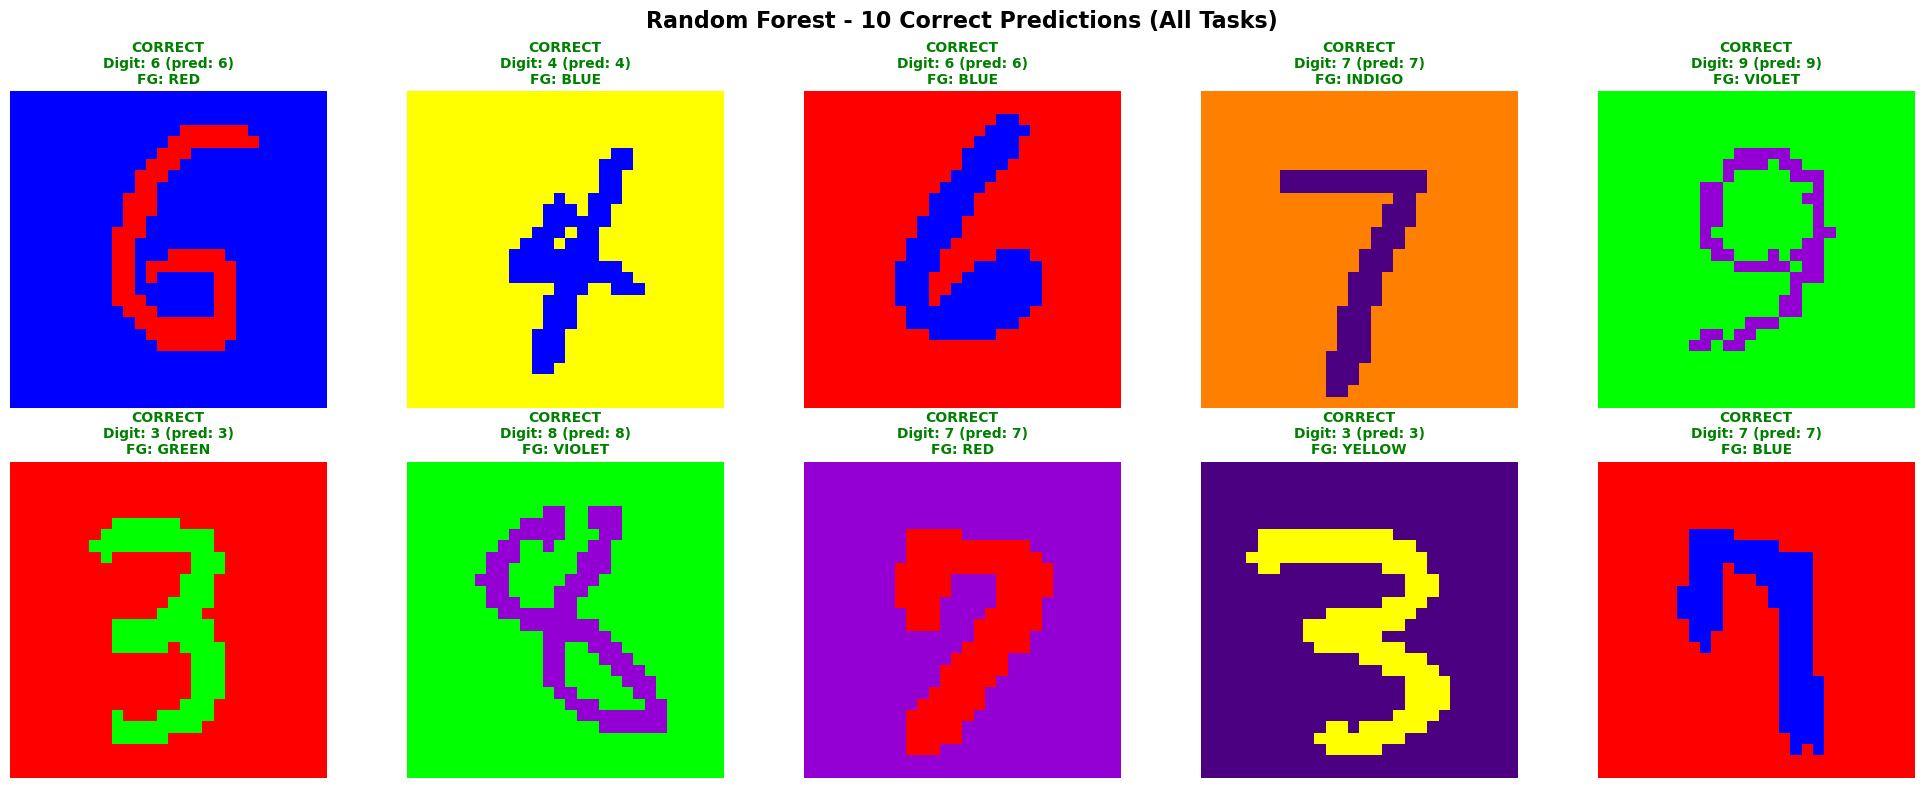


Displaying 10 Digit Classification Errors


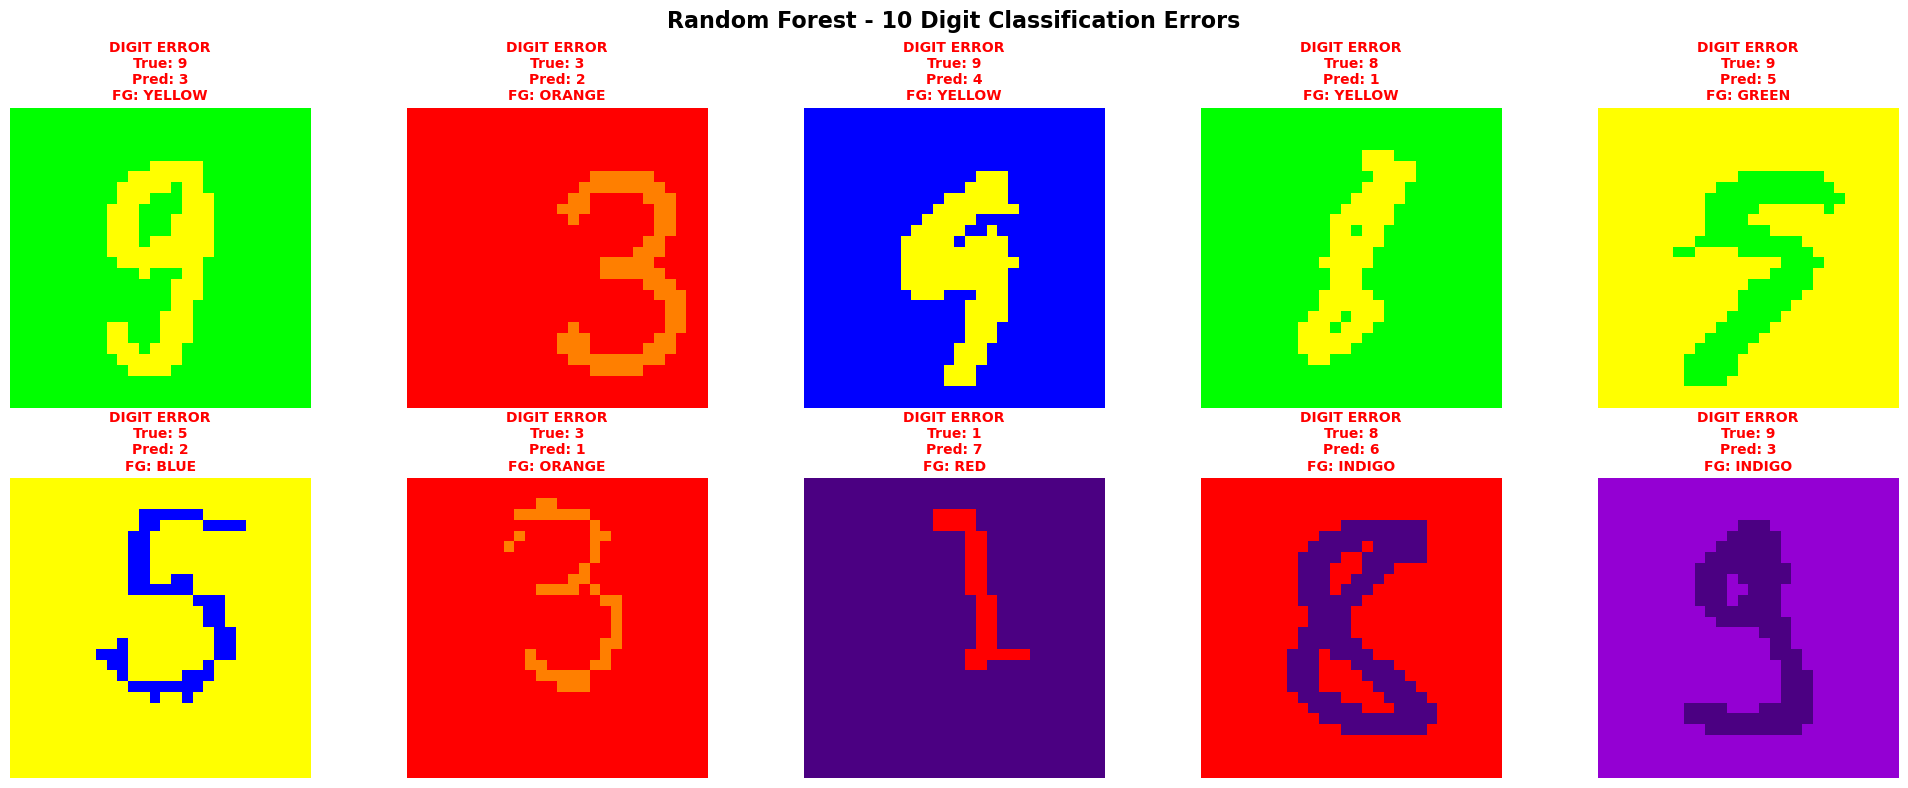


Displaying 10 Foreground Color Classification Errors


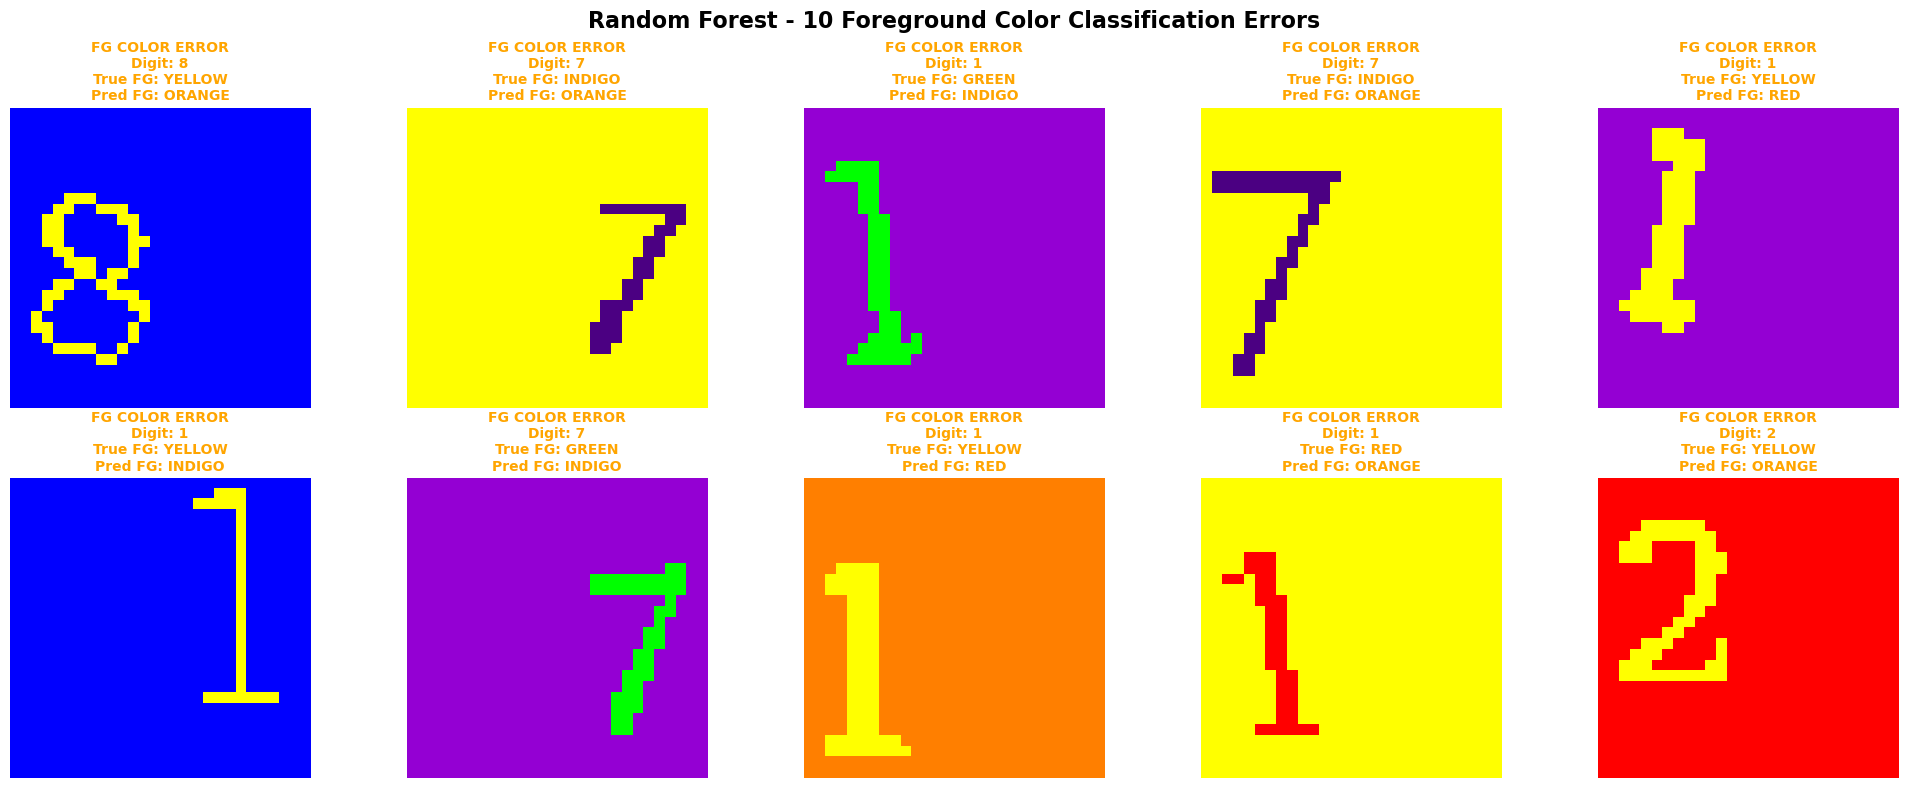


Prediction Examples Display Completed!


In [28]:
print("="*70)
print("Random Forest Prediction Examples")
print("="*70)
print("\nUsing previously trained Random Forest models and predictions...\n")

X_test_images = X_test.reshape(-1, 28, 28, 3) if X_test.shape[1] == 2352 else X_test.reshape(-1, 28, 28)

digit_correct_idx = np.where(y_digit_test == y_digit_pred_rf)[0]
digit_incorrect_idx = np.where(y_digit_test != y_digit_pred_rf)[0]

if y_fg_pred_rf is not None:
    fg_incorrect_idx = np.where(y_fg_test != y_fg_pred_rf)[0]
else:
    fg_incorrect_idx = np.array([])

print(f"Digit Classification - Correct: {len(digit_correct_idx)}, Incorrect: {len(digit_incorrect_idx)}")
if y_fg_pred_rf is not None:
    print(f"Foreground Color Classification - Incorrect: {len(fg_incorrect_idx)}")

print("\n" + "="*70)
print("Displaying 10 Correct Predictions")
print("="*70)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Random Forest - 10 Correct Predictions (All Tasks)', fontsize=16, fontweight='bold')

np.random.seed(42)
sample_correct = np.random.choice(digit_correct_idx, min(10, len(digit_correct_idx)), replace=False)

for i, ax in enumerate(axes.flat):
    if i < len(sample_correct):
        idx = sample_correct[i]
        img = X_test_images[idx]
        
        if len(img.shape) == 3 and img.shape[2] == 3:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap='gray')
        
        true_digit = y_digit_test[idx]
        pred_digit = y_digit_pred_rf[idx]
        
        title = f'CORRECT\n'
        title += f'Digit: {true_digit} (pred: {pred_digit})'
        
        if y_fg_pred_rf is not None:
            true_fg = y_fg_test[idx]
            pred_fg = y_fg_pred_rf[idx]
            true_fg_name = RAINBOW_NAMES[int(true_fg)]
            pred_fg_name = RAINBOW_NAMES[int(pred_fg)]
            title += f'\nFG: {true_fg_name}'
        
        ax.set_title(title, fontsize=10, fontweight='bold', color='green')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Displaying 10 Digit Classification Errors")
print("="*70)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Random Forest - 10 Digit Classification Errors', fontsize=16, fontweight='bold')

sample_digit_incorrect = np.random.choice(digit_incorrect_idx, min(10, len(digit_incorrect_idx)), replace=False)

for i, ax in enumerate(axes.flat):
    if i < len(sample_digit_incorrect):
        idx = sample_digit_incorrect[i]
        img = X_test_images[idx]
        
        if len(img.shape) == 3 and img.shape[2] == 3:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap='gray')
        
        true_digit = y_digit_test[idx]
        pred_digit = y_digit_pred_rf[idx]
        
        title = f'DIGIT ERROR\n'
        title += f'True: {true_digit}\n'
        title += f'Pred: {pred_digit}'
        
        if y_fg_pred_rf is not None:
            true_fg = y_fg_test[idx]
            pred_fg = y_fg_pred_rf[idx]
            true_fg_name = RAINBOW_NAMES[int(true_fg)]
            pred_fg_name = RAINBOW_NAMES[int(pred_fg)]
            title += f'\nFG: {true_fg_name}'
        
        ax.set_title(title, fontsize=10, fontweight='bold', color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

if y_fg_pred_rf is not None and len(fg_incorrect_idx) > 0:
    print("\n" + "="*70)
    print("Displaying 10 Foreground Color Classification Errors")
    print("="*70)
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Random Forest - 10 Foreground Color Classification Errors', fontsize=16, fontweight='bold')
    
    sample_fg_incorrect = np.random.choice(fg_incorrect_idx, min(10, len(fg_incorrect_idx)), replace=False)
    
    for i, ax in enumerate(axes.flat):
        if i < len(sample_fg_incorrect):
            idx = sample_fg_incorrect[i]
            img = X_test_images[idx]
            
            if len(img.shape) == 3 and img.shape[2] == 3:
                ax.imshow(img)
            else:
                ax.imshow(img, cmap='gray')
            
            true_digit = y_digit_test[idx]
            pred_digit = y_digit_pred_rf[idx]
            
            true_fg = y_fg_test[idx]
            pred_fg = y_fg_pred_rf[idx]
            true_fg_name = RAINBOW_NAMES[int(true_fg)]
            pred_fg_name = RAINBOW_NAMES[int(pred_fg)]
            
            title = f'FG COLOR ERROR\n'
            title += f'Digit: {true_digit}\n'
            title += f'True FG: {true_fg_name}\n'
            title += f'Pred FG: {pred_fg_name}'
            
            ax.set_title(title, fontsize=10, fontweight='bold', color='orange')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    if y_fg_pred_rf is None:
        print("\nNo foreground color labels available.")
    else:
        print("\nNo foreground color classification errors found.")

print("\n" + "="*70)
print("Prediction Examples Display Completed!")
print("="*70)